In [1]:
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm


def normalize(tensor):
    min_val = tensor.amin(dim=-1, keepdim=True)
    max_val = tensor.amax(dim=-1, keepdim=True)
    return (tensor - min_val) / (max_val - min_val + 1e-8)


class SpectralLoss(nn.Module):
    def __init__(self):
        super(SpectralLoss, self).__init__()

    def forward(self, x, y):
        # Apply FFT along the time dimension (last dim assumed to be time)
        x_fft = torch.fft.rfft(x, dim=-1)
        y_fft = torch.fft.rfft(y, dim=-1)

        # Compare magnitude spectrum
        x_mag = torch.abs(x_fft)
        y_mag = torch.abs(y_fft)

        return F.mse_loss(x_mag, y_mag)

class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0):
        super(CombinedLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.spectral = SpectralLoss()
        self.alpha = alpha  # weight for MSE
        self.beta = beta    # weight for spectral

    def forward(self, recon, target):
        mse_loss = self.mse(recon, target)
        spectral_loss = self.spectral(recon, target)
        return self.alpha * mse_loss + self.beta * spectral_loss


class Encoder_1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(Encoder_1, self).__init__()

        self.dropout_rate = dropout_rate
        self.conv1 = nn.Conv2d(1, 128, kernel_size=(1, 5), stride=(1,2) ,padding=(0, 0)) 
        self.batchnorm1 = nn.BatchNorm2d(128)  
        self.dropout1 = nn.Dropout(self.dropout_rate)
        self.conv2 = nn.Conv2d(128, 256, kernel_size=(1, 3), stride=(1,1) ,padding=(0, 0))   
        self.batchnorm2 = nn.BatchNorm2d(256)
        self.dropout2 = nn.Dropout(self.dropout_rate)
        self.conv3 = nn.Conv2d(256, 512, kernel_size=(1, 3), stride=(1,2) ,padding=(0, 0))   
        self.batchnorm3 = nn.BatchNorm2d(512)
        self.dropout3 = nn.Dropout(self.dropout_rate)
        self.conv4 = nn.Conv2d(512, 1, kernel_size=(1, 3), stride=(1,1) ,padding=(0, 0))   
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        # print(x.shape)
        x = F.relu(self.conv1(x))
        x = self.batchnorm1(x)
        x = self.dropout1(x)
        # print(x.shape)
        x = self.leaky_relu(self.conv2(x))
        x = self.batchnorm2(x)
        x = self.dropout2(x)
        # print(x.shape)
        x = F.elu(self.conv3(x)); 
        x = self.batchnorm3(x)
        x = self.dropout3(x)
        # print(x.shape)
        x = self.conv4(x); 
        # print(x.shape)
        return x 

class Decoder_1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        self.dropout_rate = dropout_rate

        super(Decoder_1, self).__init__()
        self.deconv1 = nn.ConvTranspose2d(1, 512, kernel_size=(1, 3), stride=(1, 1))   
        self.deconv1_bn = nn.BatchNorm2d(512)
        self.deconv1_dp = nn.Dropout(self.dropout_rate)            
        self.deconv2 = nn.ConvTranspose2d(512, 256, kernel_size=(1, 3), stride=(1, 2), output_padding=(0, 1))  # W: 34 → 69
        self.deconv2_bn = nn.BatchNorm2d(256)
        self.deconv2_dp = nn.Dropout(self.dropout_rate)
        self.deconv3 = nn.ConvTranspose2d(256, 128, kernel_size=(1, 3), stride=(1, 1), output_padding=(0, 0))   # W: 69 → 141
        self.deconv3_bn = nn.BatchNorm2d(128)
        self.deconv3_dp = nn.Dropout(self.dropout_rate)
        self.deconv4 = nn.ConvTranspose2d(128, 1, kernel_size=(1, 5), stride=(1, 2), output_padding=(0, 1))    # W: 141 → 300

    def forward(self, x):
        x = F.relu(self.deconv1(x))         
        x = self.deconv1_bn(x)
        x = self.deconv1_dp(x)
        # print("deconv1:", x.shape)
        x = F.softplus(self.deconv2(x))     # (B, 64, 1, 69)
        x = self.deconv2_bn(x)
        x = self.deconv2_dp(x)
        # print("deconv2:", x.shape)
        x = F.elu(self.deconv3(x))          # (B, 32, 1, 141)
        x = self.deconv3_bn(x)
        x = self.deconv3_dp(x)
        # print("deconv3:", x.shape)
        # x = F.tanh(self.deconv4(x))         # (B, 5, 1, 300)
        x = (self.deconv4(x))         # (B, 5, 1, 300)
        # print("deconv4:", x.shape)
        return x

        
class Autoencoder_type1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(Autoencoder_type1, self).__init__()
        self.dropout_rate = dropout_rate
        self.encoder = Encoder_1(self.dropout_rate)
        self.decoder = Decoder_1(self.dropout_rate)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent


if __name__ == "__main__":
    x = torch.randn(133, 1, 8, 400)# Example input (B=1, C=1, H=1, W=200)
    model1 = Autoencoder_type1(dropout_rate=0.2)
    reconstructed, latent = model1(x)
    print("Input shape:", x.shape)
    print("Reconstructed shape:", reconstructed.shape) 
    print("Latent shape:", latent.shape) 

Input shape: torch.Size([133, 1, 8, 400])
Reconstructed shape: torch.Size([133, 1, 8, 400])
Latent shape: torch.Size([133, 1, 8, 95])


Reference latent space acquired
Ablating sensor 1/8
Ablating sensor 2/8
Ablating sensor 3/8
Ablating sensor 4/8
Ablating sensor 5/8
Ablating sensor 6/8
Ablating sensor 7/8
Ablating sensor 8/8


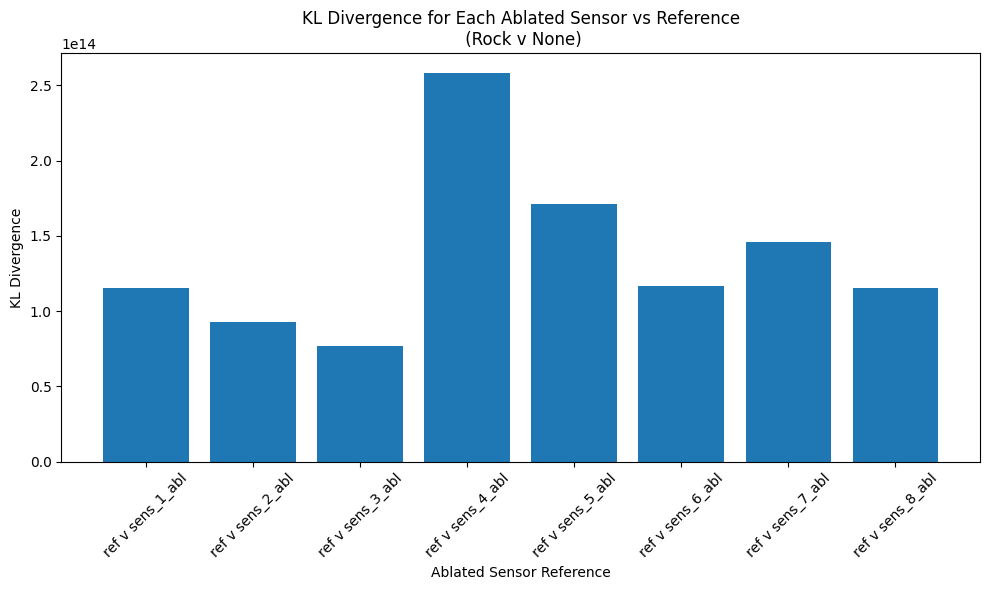

Rock KL divergence values: [115566899625984.0, 92854567305216.0, 76800558366720.0, 258419273498624.0, 170876968370176.0, 117004455378944.0, 146112321159168.0, 115506493259776.0]


In [2]:
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm


# AE model v2 was trained on data augmented with zeros
rock_ae_weights = torch.load("param_autoencoder_rock_v2.pth", map_location=torch.device('mps'))
rock_ae = Autoencoder_type1(dropout_rate=0.2)
rock_ae.load_state_dict(rock_ae_weights)
rock_ae.eval()

num_sensors = 8

dir_loaders = 'dataloaders'
rock_loader = torch.load(os.path.join(dir_loaders, 'rock_dataloader_zeros.pt'), weights_only=False)

all_x = []
for x, _ in rock_loader:
    all_x.append(x)
all_x = torch.cat(all_x, dim=0)
x = all_x

# reference + ablated latent spaces: [8]
mus = torch.zeros((num_sensors+1, num_sensors))
# reference + ablated latent spaces: [8, 8]
sigmas = torch.zeros((num_sensors+1, num_sensors, num_sensors))

# reference latent spaces (without ablation)
_, latent_reference = rock_ae(x) # Shape: [133, 1, 8, 95]
latent_reference = latent_reference.squeeze(1).mean(0) 

mus[0] = latent_reference.mean(1)
sigmas[0] = latent_reference.cov()
print("Reference latent space acquired")

with torch.no_grad():
    for ablated_sensor in range(num_sensors):
        print(f"Ablating sensor {ablated_sensor + 1}/{num_sensors}")

        # Ablate sensor
        x_ablated = x.clone()
        x_ablated[:, :, ablated_sensor, :] = 0.0

        # Get latent space
        _, latent = rock_ae(x_ablated)
        
        latent = latent.squeeze(1).mean(0) # Shape: [8, 95]

        mus[ablated_sensor + 1] = latent.mean(1)
        sigmas[ablated_sensor + 1] = latent.cov()
        

def kld_multivariate_gaussian(mu0, sigma0, mu1, sigma1):
    """
    Compute KL divergence D_KL(N0 || N1) between two multivariate Gaussians N0(mu0, sigma0), N1(mu1, sigma1)
    """
    k = mu0.shape[0]
    sigma1_inv = torch.linalg.inv(sigma1)
    diff = (mu1 - mu0).unsqueeze(1)  # shape [k, 1]
    trace_term = torch.trace(sigma1_inv @ sigma0)
    mahalanobis = (diff.T @ sigma1_inv @ diff).squeeze()
    log_det0 = torch.logdet(sigma0)
    log_det1 = torch.logdet(sigma1)
    kld = 0.5 * (log_det1 - log_det0 - k + trace_term + mahalanobis)
    return kld.item()

kld_vals_rock = []
for i in range(1, num_sensors+1):
    mu_ref = mus[0]
    sigma_ref = sigmas[0]
    mu_ab = mus[i]
    sigma_ab = sigmas[i]
    kld = kld_multivariate_gaussian(mu_ref, sigma_ref, mu_ab, sigma_ab)
    kld_vals_rock.append(kld)


# Create labels for each ablated sensor
labels = [f"ref v sens_{i}_abl" for i in range(1, num_sensors+1)]

plt.figure(figsize=(10, 6))
plt.bar(labels, kld_vals_rock)
plt.xlabel("Ablated Sensor Reference")
plt.xticks(rotation=45)
plt.ylabel("KL Divergence")
plt.title("KL Divergence for Each Ablated Sensor vs Reference\n (Rock v None)")
plt.tight_layout()
plt.show()

print("Rock KL divergence values:", kld_vals_rock)


Paper reference latent space acquired
Ablating sensor 1/8
Ablating sensor 2/8
Ablating sensor 3/8
Ablating sensor 4/8
Ablating sensor 5/8
Ablating sensor 6/8
Ablating sensor 7/8
Ablating sensor 8/8


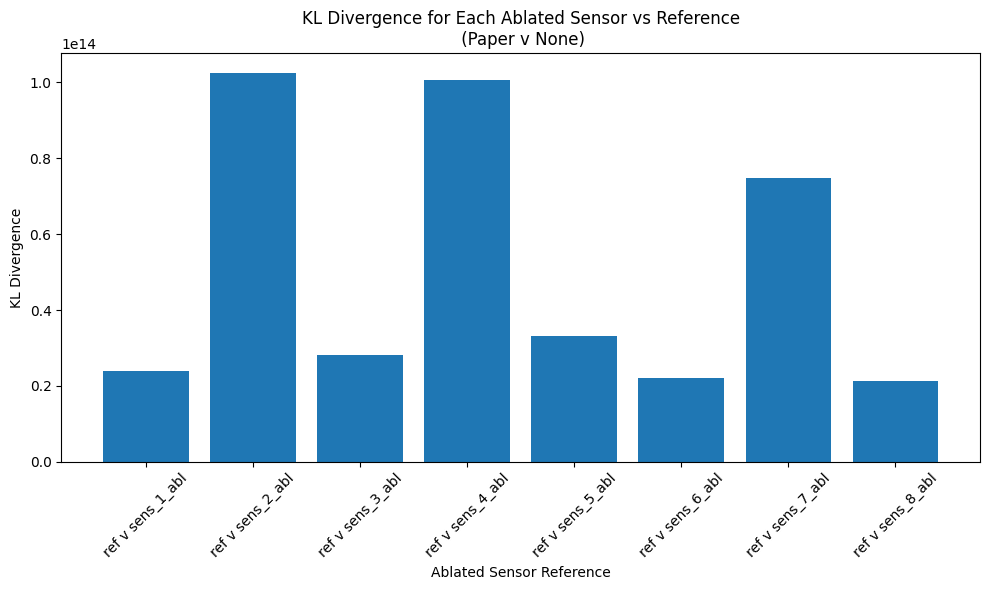

Paper KL divergence values: [23854160281600.0, 102610963005440.0, 28114845433856.0, 100752601120768.0, 33194084663296.0, 21972079607808.0, 74897694916608.0, 21232216965120.0]


In [3]:
# Paper v None Analysis
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load paper AE model (trained on data augmented with zeros)
paper_ae_weights = torch.load("param_autoencoder_paper_v2.pth", map_location=torch.device('mps'))
paper_ae = Autoencoder_type1(dropout_rate=0.2)
paper_ae.load_state_dict(paper_ae_weights)
paper_ae.eval()

num_sensors = 8

# Load paper dataloader
dir_loaders = 'dataloaders'
paper_loader = torch.load(os.path.join(dir_loaders, 'paper_dataloader_zeros.pt'), weights_only=False)

all_x = []
for x, _ in paper_loader:
    all_x.append(x)
all_x = torch.cat(all_x, dim=0)
x = all_x

# reference + ablated latent spaces: [8]
mus_paper = torch.zeros((num_sensors+1, num_sensors))
# reference + ablated latent spaces: [8, 8]
sigmas_paper = torch.zeros((num_sensors+1, num_sensors, num_sensors))

# reference latent spaces (without ablation)
_, latent_reference = paper_ae(x) # Shape: [133, 1, 8, 95]
latent_reference = latent_reference.squeeze(1).mean(0) 

mus_paper[0] = latent_reference.mean(1)
sigmas_paper[0] = latent_reference.cov()
print("Paper reference latent space acquired")

with torch.no_grad():
    for ablated_sensor in range(num_sensors):
        print(f"Ablating sensor {ablated_sensor + 1}/{num_sensors}")

        # Ablate sensor
        x_ablated = x.clone()
        x_ablated[:, :, ablated_sensor, :] = 0.0

        # Get latent space
        _, latent = paper_ae(x_ablated)
        
        latent = latent.squeeze(1).mean(0) # Shape: [8, 95]

        mus_paper[ablated_sensor + 1] = latent.mean(1)
        sigmas_paper[ablated_sensor + 1] = latent.cov()

# Calculate KL divergences for paper
kld_vals_paper = []
for i in range(1, num_sensors+1):
    mu_ref = mus_paper[0]
    sigma_ref = sigmas_paper[0]
    mu_ab = mus_paper[i]
    sigma_ab = sigmas_paper[i]
    kld = kld_multivariate_gaussian(mu_ref, sigma_ref, mu_ab, sigma_ab)
    kld_vals_paper.append(kld)

# Create labels for each ablated sensor
labels = [f"ref v sens_{i}_abl" for i in range(1, num_sensors+1)]

plt.figure(figsize=(10, 6))
plt.bar(labels, kld_vals_paper)
plt.xlabel("Ablated Sensor Reference")
plt.xticks(rotation=45)
plt.ylabel("KL Divergence")
plt.title("KL Divergence for Each Ablated Sensor vs Reference\n (Paper v None)")
plt.tight_layout()
plt.show()

print("Paper KL divergence values:", kld_vals_paper)


Scissor reference latent space acquired
Ablating sensor 1/8
Ablating sensor 2/8
Ablating sensor 3/8
Ablating sensor 4/8
Ablating sensor 5/8
Ablating sensor 6/8
Ablating sensor 7/8
Ablating sensor 8/8


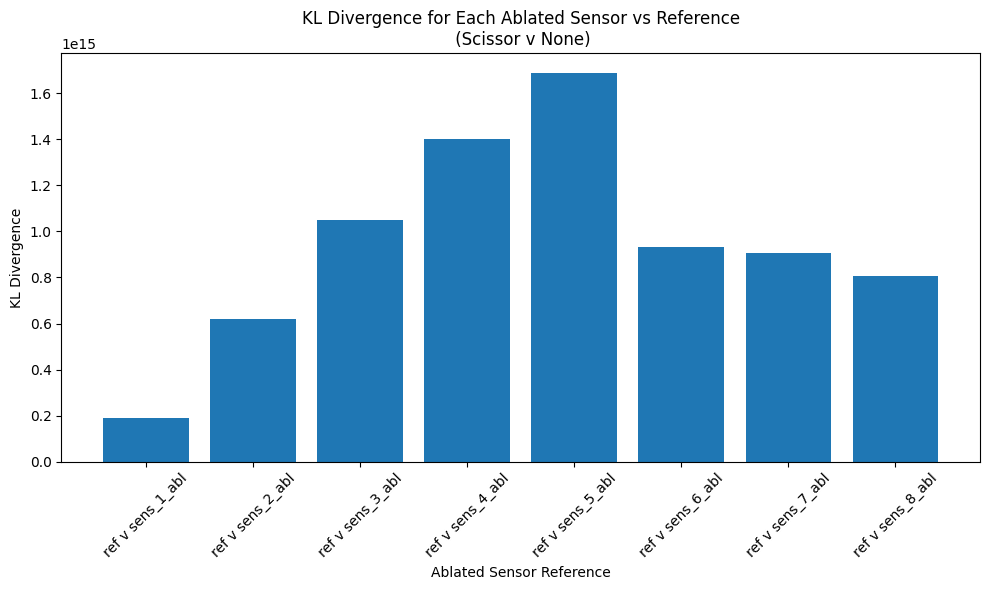

Scissor KL divergence values: [190003766362112.0, 618575014395904.0, 1049718998171648.0, 1401384477917184.0, 1689733952438272.0, 933232438673408.0, 904339992346624.0, 807406741225472.0]


In [4]:
# Scissor v None Analysis
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load scissor AE model (trained on data augmented with zeros)
scissor_ae_weights = torch.load("param_autoencoder_scissor_v2.pth", map_location=torch.device('mps'))
scissor_ae = Autoencoder_type1(dropout_rate=0.2)
scissor_ae.load_state_dict(scissor_ae_weights)
scissor_ae.eval()

num_sensors = 8

# Load scissor dataloader
dir_loaders = 'dataloaders'
scissor_loader = torch.load(os.path.join(dir_loaders, 'scissor_dataloader_zeros.pt'), weights_only=False)

all_x = []
for x, _ in scissor_loader:
    all_x.append(x)
all_x = torch.cat(all_x, dim=0)
x = all_x

# reference + ablated latent spaces: [8]
mus_scissor = torch.zeros((num_sensors+1, num_sensors))
# reference + ablated latent spaces: [8, 8]
sigmas_scissor = torch.zeros((num_sensors+1, num_sensors, num_sensors))

# reference latent spaces (without ablation)
_, latent_reference = scissor_ae(x) # Shape: [133, 1, 8, 95]
latent_reference = latent_reference.squeeze(1).mean(0) 

mus_scissor[0] = latent_reference.mean(1)
sigmas_scissor[0] = latent_reference.cov()
print("Scissor reference latent space acquired")

with torch.no_grad():
    for ablated_sensor in range(num_sensors):
        print(f"Ablating sensor {ablated_sensor + 1}/{num_sensors}")

        # Ablate sensor
        x_ablated = x.clone()
        x_ablated[:, :, ablated_sensor, :] = 0.0

        # Get latent space
        _, latent = scissor_ae(x_ablated)
        
        latent = latent.squeeze(1).mean(0) # Shape: [8, 95]

        mus_scissor[ablated_sensor + 1] = latent.mean(1)
        sigmas_scissor[ablated_sensor + 1] = latent.cov()

# Calculate KL divergences for scissor
kld_vals_scissor = []
for i in range(1, num_sensors+1):
    mu_ref = mus_scissor[0]
    sigma_ref = sigmas_scissor[0]
    mu_ab = mus_scissor[i]
    sigma_ab = sigmas_scissor[i]
    kld = kld_multivariate_gaussian(mu_ref, sigma_ref, mu_ab, sigma_ab)
    kld_vals_scissor.append(kld)

# Create labels for each ablated sensor
labels = [f"ref v sens_{i}_abl" for i in range(1, num_sensors+1)]

plt.figure(figsize=(10, 6))
plt.bar(labels, kld_vals_scissor)
plt.xlabel("Ablated Sensor Reference")
plt.xticks(rotation=45)
plt.ylabel("KL Divergence")
plt.title("KL Divergence for Each Ablated Sensor vs Reference\n (Scissor v None)")
plt.tight_layout()
plt.show()

print("Scissor KL divergence values:", kld_vals_scissor)


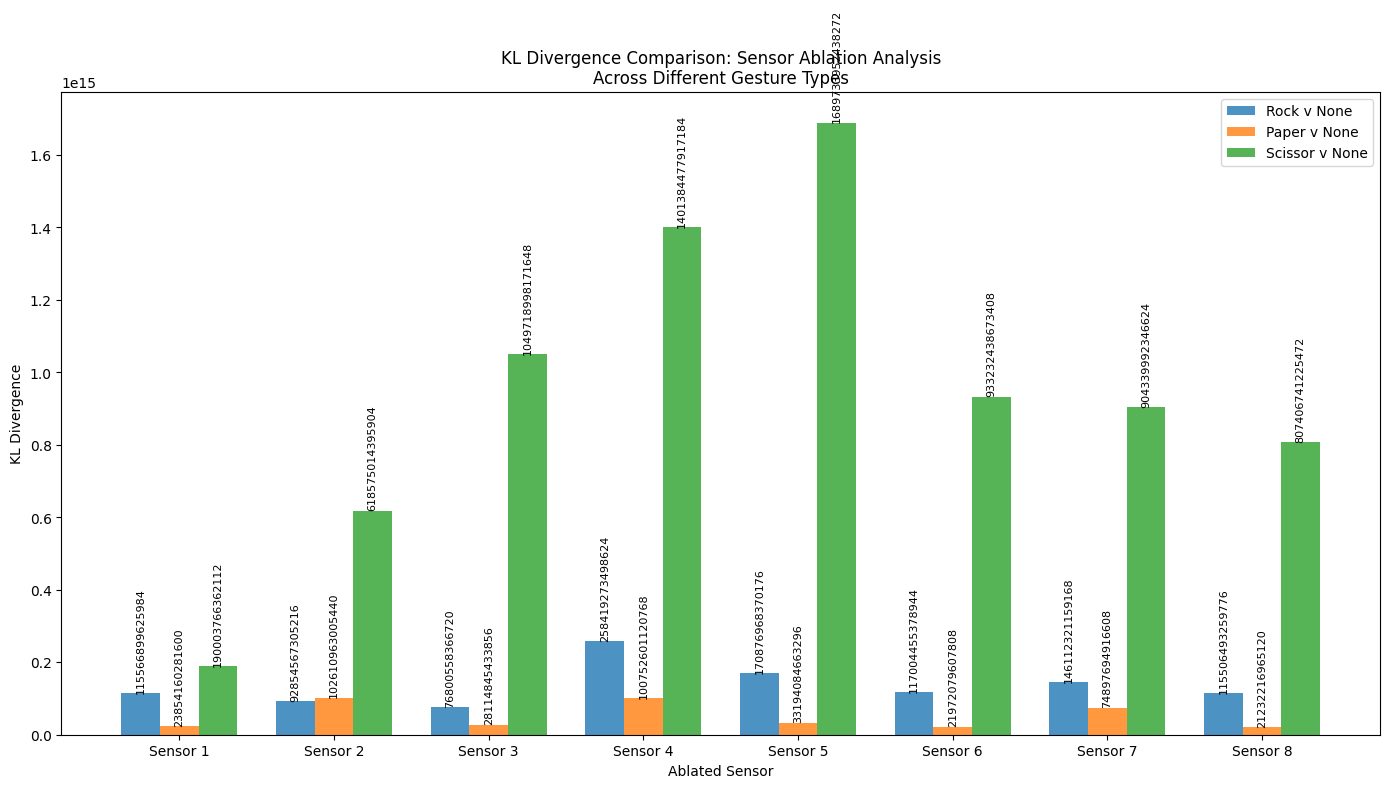

Summary of KL Divergence Values:
Rock v None - Mean: 136642692120576, Std: 53462912890065
Paper v None - Mean: 50828580749312, Std: 33571372049152
Scissor v None - Mean: 949299422691328, Std: 428810832493258

Detailed KL Divergence Values:
     Sensor   Rock_v_None  Paper_v_None  Scissor_v_None
0  Sensor 1  1.155669e+14  2.385416e+13    1.900038e+14
1  Sensor 2  9.285457e+13  1.026110e+14    6.185750e+14
2  Sensor 3  7.680056e+13  2.811485e+13    1.049719e+15
3  Sensor 4  2.584193e+14  1.007526e+14    1.401384e+15
4  Sensor 5  1.708770e+14  3.319408e+13    1.689734e+15
5  Sensor 6  1.170045e+14  2.197208e+13    9.332324e+14
6  Sensor 7  1.461123e+14  7.489769e+13    9.043400e+14
7  Sensor 8  1.155065e+14  2.123222e+13    8.074067e+14


In [5]:
# Comparison Plot: All Three Analyses
import matplotlib.pyplot as plt
import numpy as np

# Combine all KL divergence values
# Note: Make sure all previous cells have been run to have these variables available
# kld_vals (rock), kld_vals_paper, kld_vals_scissor

# Create sensor labels
sensor_labels = [f"Sensor {i}" for i in range(1, 9)]

# Set up the plot
x = np.arange(len(sensor_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

# Create bars for each condition
bars1 = ax.bar(x - width, kld_vals_rock, width, label='Rock v None', alpha=0.8)
bars2 = ax.bar(x, kld_vals_paper, width, label='Paper v None', alpha=0.8)
bars3 = ax.bar(x + width, kld_vals_scissor, width, label='Scissor v None', alpha=0.8)

# Customize the plot
ax.set_xlabel('Ablated Sensor')
ax.set_ylabel('KL Divergence')
ax.set_title('KL Divergence Comparison: Sensor Ablation Analysis\nAcross Different Gesture Types')
ax.set_xticks(x)
ax.set_xticklabels(sensor_labels)
ax.legend()

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom', fontsize=8, rotation=90)

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary of KL Divergence Values:")
print("================================")
print(f"Rock v None - Mean: {np.mean(kld_vals_rock):.0f}, Std: {np.std(kld_vals_rock):.0f}")
print(f"Paper v None - Mean: {np.mean(kld_vals_paper):.0f}, Std: {np.std(kld_vals_paper):.0f}")
print(f"Scissor v None - Mean: {np.mean(kld_vals_scissor):.0f}, Std: {np.std(kld_vals_scissor):.0f}")

# Create a summary dataframe for easier analysis
import pandas as pd
summary_df = pd.DataFrame({
    'Sensor': sensor_labels,
    'Rock_v_None': kld_vals_rock,
    'Paper_v_None': kld_vals_paper,
    'Scissor_v_None': kld_vals_scissor
})

print("\nDetailed KL Divergence Values:")
print(summary_df)
